# 03. Modelagem e Avaliação

In [1]:
import sys
import warnings

sys.path.append('./src')

import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

from xgboost import XGBClassifier
import umap

import optuna

from preprocessing import carregar_e_limpar, obter_ou_criar_split
from avaliacao import (
    avaliar_modelo,
    comparar_modelos_bootstrap,
    top_features_por_classe,
    pr_auc_macro,
)
from modelagem import construir_modelos_candidatos, rodar_grade_comparativa

warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

C:\Users\MarianaCostadeMello\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = carregar_e_limpar('data/raw/dataset_ecommerce.csv')

le = LabelEncoder()
y = le.fit_transform(df['categoria'])

idx_train, idx_test = obter_ou_criar_split(df, y, caminho_split='data/processed/split.npz', test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]
texto_train = df['texto'].to_numpy(dtype=object)[idx_train]  
texto_test = df['texto'].to_numpy(dtype=object)[idx_test]

print(f"Treino: {len(idx_train)} | Teste: {len(idx_test)}")

Treino: 22241 | Teste: 5561


## 1. Baseline

Antes de treinar qualquer modelo de verdade, vale estabelecer uma referência simples: prever sempre a classe majoritária. Um modelo só é útil na prática se conseguir superar esse baseline.

In [3]:
baseline_data = np.load('data/processed/embeddings_reducoes/pca_10.npz')
X_tr_base, X_te_base = baseline_data['X_train'], baseline_data['X_test']

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
metricas_baseline, y_pred_dummy = avaliar_modelo(
    'Baseline (classe majoritária)', dummy, X_tr_base, y_train, X_te_base, y_test
)
print("Baseline (prevê sempre a classe majoritária):")
for k, v in metricas_baseline.items():
    if k != 'modelo':
        print(f"  {k}: {v:.3f}")

Baseline (prevê sempre a classe majoritária):
  accuracy: 0.380
  balanced_accuracy: 0.250
  precision_macro: 0.095
  recall_macro: 0.250
  f1_macro: 0.138
  f1_weighted: 0.209


## 2 e 3. Modelos, PCA, UMAP e TF-IDF

Para essa comparação, foram escolhidos cinco modelos: a Logistic Regression, simples e linear, e quatro modelos baseados em árvores, com naturezas diferentes entre si. Random Forest e Extra Trees são exemplos de bagging, enquanto HistGradientBoosting e XGBoost são exemplos de boosting.

Foram testados os cinco modelos com as representações salvas no notebook anterior: PCA e UMAP, cada uma nas três dimensões (10, 20 e 30), e o TF-IDF, em alta dimensão (5000 palavras, sem nenhuma redução). Uma exceção fica de fora: o HistGradientBoosting não aceita entrada esparsa nesta versão do scikit-learn, então essa combinação específica é pulada

In [4]:
modelos = construir_modelos_candidatos()

resultados, predicoes_cache, embeddings_cache = rodar_grade_comparativa(
    y_train, y_test, modelos=modelos
)


[AVISO] HistGradientBoosting pulado para TF-IDF (não suporta entrada esparsa).


## Tabela comparativa

In [5]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados[['reducao', 'dim', 'modelo', 'accuracy', 'precision_macro',
                                'recall_macro', 'f1_macro', 'f1_weighted', 'balanced_accuracy']]
df_resultados = df_resultados.sort_values('f1_macro', ascending=False).reset_index(drop=True)
df_resultados

,reducao,dim,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,balanced_accuracy
0,TF-IDF,5000,Logistic,0.947851,0.951131,0.944113,0.947447,0.947777,0.944113
1,UMAP,10,Random Forest,0.941018,0.942119,0.940461,0.940996,0.940944,0.940461
2,UMAP,20,HistGradientBoosting,0.938860,0.940185,0.937916,0.938691,0.938792,0.937916
3,UMAP,20,Random Forest,0.938320,0.939431,0.938187,0.938415,0.938247,0.938187
4,UMAP,10,Extra Trees,0.937781,0.939304,0.936813,0.937747,0.937698,0.936813
5,UMAP,10,XGBoost,0.937601,0.939395,0.936237,0.937520,0.937538,0.936237
6,UMAP,30,Random Forest,0.937421,0.938813,0.936445,0.937284,0.937350,0.936445
7,UMAP,10,HistGradientBoosting,0.937062,0.937683,0.937053,0.937070,0.937021,0.937053
8,UMAP,20,XGBoost,0.936702,0.938060,0.935568,0.936516,0.936653,0.935568
9,UMAP,30,HistGradientBoosting,0.936342,0.937989,0.935445,0.936413,0.936296,0.935445


## 4. Escolhendo as configurações para otimizar

In [6]:
resultados_xgb = df_resultados[df_resultados['modelo'] == 'XGBoost'].sort_values('f1_macro', ascending=False)
melhor_xgb = resultados_xgb.iloc[0]
xgb_reducao, xgb_dim = melhor_xgb['reducao'], int(melhor_xgb['dim'])
print(f"Melhor configuração para XGBoost: {xgb_reducao} {xgb_dim}D (F1-macro={melhor_xgb['f1_macro']:.3f})")

X_tr_xgb, X_te_xgb = embeddings_cache[(xgb_reducao, xgb_dim)]

resultados_log = df_resultados[df_resultados['modelo'] == 'Logistic'].sort_values('f1_macro', ascending=False)
melhor_log = resultados_log.iloc[0]
log_reducao, log_dim = melhor_log['reducao'], int(melhor_log['dim'])
print(f"Melhor configuração para Logistic Regression: {log_reducao} {log_dim}D (F1-macro={melhor_log['f1_macro']:.3f})")

X_tr_log, X_te_log = embeddings_cache[(log_reducao, log_dim)]

Melhor configuração para XGBoost: UMAP 10D (F1-macro=0.938)
Melhor configuração para Logistic Regression: TF-IDF 5000D (F1-macro=0.947)


## 5. Otimização com Optuna

Para não usar o conjunto de teste durante a busca de hiperparâmetros, o que seria um vazamento de dados, foi separado uma fatia de validação dentro do próprio treino. Os mesmos índices de treino/validação são usados para os dois modelos, então a comparação entre eles fica justa.

In [7]:
idx_tr_train, idx_tr_val = train_test_split(
    np.arange(len(y_train)), test_size=0.2, random_state=42, stratify=y_train
)
y_opt_train, y_opt_val = y_train[idx_tr_train], y_train[idx_tr_val]

X_opt_train_xgb, X_opt_val_xgb = X_tr_xgb[idx_tr_train], X_tr_xgb[idx_tr_val]
X_opt_train_log, X_opt_val_log = X_tr_log[idx_tr_train], X_tr_log[idx_tr_val]

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': 2,
    }
    modelo = XGBClassifier(**params)
    modelo.fit(X_opt_train_xgb, y_opt_train)
    y_pred = modelo.predict(X_opt_val_xgb)
    return f1_score(y_opt_val, y_pred, average='macro')

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=25)

melhores_params_xgb = study_xgb.best_params.copy()
melhores_params_xgb.update({'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': 2})

print(f"[XGBoost] Configuração: {xgb_reducao} {xgb_dim}D")
print(f"[XGBoost] Melhor F1-macro (validação): {study_xgb.best_value:.3f}")
print(f"[XGBoost] Melhores hiperparâmetros: {study_xgb.best_params}")


def objective_logistic(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'max_iter': 2000,
        'random_state': 42,
    }
    modelo = LogisticRegression(**params)
    modelo.fit(X_opt_train_log, y_opt_train)
    y_pred = modelo.predict(X_opt_val_log)
    return f1_score(y_opt_val, y_pred, average='macro')

study_log = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_log.optimize(objective_logistic, n_trials=25)

melhores_params_log = study_log.best_params.copy()
melhores_params_log.update({'max_iter': 2000, 'random_state': 42})

print(f"\n[Logistic] Configuração: {log_reducao} {log_dim}D")
print(f"[Logistic] Melhor F1-macro (validação): {study_log.best_value:.3f}")
print(f"[Logistic] Melhores hiperparâmetros: {study_log.best_params}")

[XGBoost] Configuração: UMAP 10D
[XGBoost] Melhor F1-macro (validação): 0.947
[XGBoost] Melhores hiperparâmetros: {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.019721610970574007, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.836965827544817, 'min_child_weight': 1}

[Logistic] Configuração: TF-IDF 5000D
[Logistic] Melhor F1-macro (validação): 0.953
[Logistic] Melhores hiperparâmetros: {'C': 4.549349882568909, 'class_weight': 'balanced'}


## 6. Validação cruzada (5-fold)

Usar o X_tr_xgb ou X_tr_log já reduzido no cross_validate causaria vazamento, pois o TF-IDF/UMAP já teria usado os dados dos folds de validação.

Por isso, cada modelo finalista é colocado em um Pipeline com a representação e o modelo. Assim, em cada fold, o fit é feito apenas com os dados de treino daquele fold, evitando vazamento e deixando a validação mais confiável.

5-fold CV, XGBoost otimizado (UMAP 10D), pipeline refeito a cada fold:
  f1_macro         média=0.941 +/- 0.003 | valores=[0.939 0.939 0.938 0.946 0.944]
  accuracy         média=0.941 +/- 0.003 | valores=[0.94  0.939 0.938 0.946 0.943]
  precision_macro  média=0.943 +/- 0.003 | valores=[0.941 0.943 0.939 0.948 0.946]
  recall_macro     média=0.940 +/- 0.004 | valores=[0.938 0.936 0.937 0.946 0.942]

5-fold CV, Logistic Regression otimizada (TF-IDF 5000D), pipeline refeito a cada fold:
  f1_macro         média=0.946 +/- 0.003 | valores=[0.946 0.941 0.948 0.95  0.944]
  accuracy         média=0.946 +/- 0.003 | valores=[0.947 0.942 0.948 0.95  0.944]
  precision_macro  média=0.946 +/- 0.003 | valores=[0.947 0.941 0.947 0.95  0.943]
  recall_macro     média=0.946 +/- 0.003 | valores=[0.946 0.941 0.949 0.949 0.944]


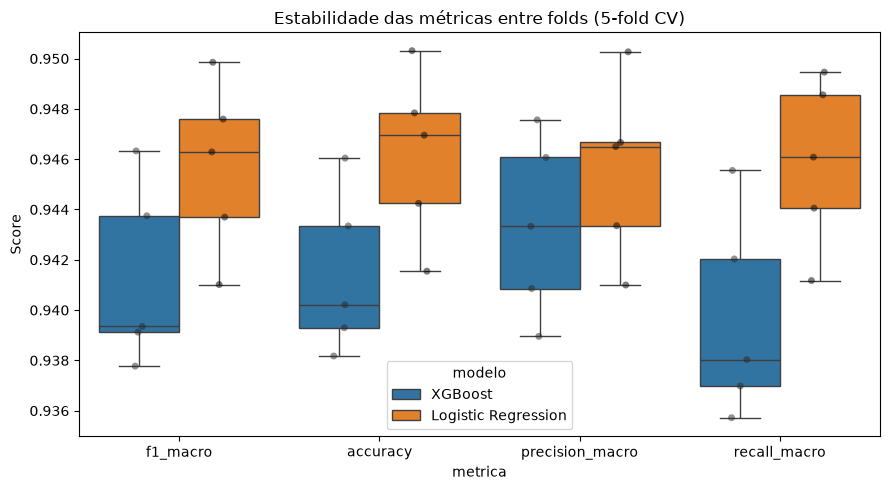

In [8]:
scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline_log = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=2)),
    ('clf', LogisticRegression(**melhores_params_log)),
])
scores_cv_log = cross_validate(pipeline_log, texto_train, y_train, cv=skf, scoring=scoring)


embeddings_completos = np.load('data/raw/embeddings_texto.npy')
from preprocessing import carregar_embeddings_alinhados
embeddings_alinhados = carregar_embeddings_alinhados('data/raw/embeddings_texto.npy', df)
emb_train_bruto = embeddings_alinhados[idx_train]

pipeline_xgb = Pipeline([
    ('umap', umap.UMAP(n_components=xgb_dim, n_jobs=2)),
    ('clf', XGBClassifier(**melhores_params_xgb)),
])
scores_cv_xgb = cross_validate(pipeline_xgb, emb_train_bruto, y_train, cv=skf, scoring=scoring)

print(f"5-fold CV, XGBoost otimizado ({xgb_reducao} {xgb_dim}D), pipeline refeito a cada fold:")
for metrica in scoring:
    vals = scores_cv_xgb[f'test_{metrica}']
    print(f"  {metrica:16s} média={vals.mean():.3f} +/- {vals.std():.3f} | valores={np.round(vals, 3)}")

print(f"\n5-fold CV, Logistic Regression otimizada ({log_reducao} {log_dim}D), pipeline refeito a cada fold:")
for metrica in scoring:
    vals = scores_cv_log[f'test_{metrica}']
    print(f"  {metrica:16s} média={vals.mean():.3f} +/- {vals.std():.3f} | valores={np.round(vals, 3)}")

dados_cv_xgb = pd.DataFrame({m: scores_cv_xgb[f'test_{m}'] for m in scoring})
dados_cv_xgb['modelo'] = 'XGBoost'
dados_cv_log = pd.DataFrame({m: scores_cv_log[f'test_{m}'] for m in scoring})
dados_cv_log['modelo'] = 'Logistic Regression'
dados_cv = pd.concat([dados_cv_xgb, dados_cv_log], ignore_index=True)
dados_cv_long = dados_cv.melt(id_vars='modelo', var_name='metrica', value_name='score')

plt.figure(figsize=(9, 5))
sns.boxplot(data=dados_cv_long, x='metrica', y='score', hue='modelo')
sns.stripplot(data=dados_cv_long, x='metrica', y='score', hue='modelo', dodge=True, color='black', alpha=0.5, legend=False)
plt.title('Estabilidade das métricas entre folds (5-fold CV)')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('figs/03_cv_estabilidade.png', dpi=100)
plt.show()

- Logistic Regression acima do XGBoost nas 4 métricas, de forma consistente entre folds.
- Precision_macro é onde eles mais se aproximam (caixas quase encostando).
- Recall_macro é onde a diferença é maior, XGBoost bem mais espalhado e mais baixo.
- Mesma conclusão do gráfico anterior: Logistic ganha e é mais estável.

## 7. Avaliação final no teste

XGBoost otimizado   (UMAP 10D), F1 macro: 0.940 | F1 weighted: 0.940 | ROC-AUC: 0.986 | PR-AUC macro: 0.966
Logistic otimizada  (TF-IDF 5000D), F1 macro: 0.948 | F1 weighted: 0.948 | ROC-AUC: 0.991 | PR-AUC macro: 0.978

[Nota] O ROC-AUC dos dois modelos está muito perto de 1 e diferencia pouco entre eles. Isso é esperado num problema com boa separação entre classes como este. O PR-AUC por classe é reportado ao lado por ser mais sensível ao desbalanceamento residual entre categorias.

Vencedor: Logistic Regression (TF-IDF 5000D), F1-macro=0.948

                      precision    recall  f1-score   support

               Books       0.94      0.93      0.94      1251
Clothing_Accessories       0.97      0.98      0.98      1135
         Electronics       0.93      0.93      0.93      1062
           Household       0.95      0.95      0.95      2113

            accuracy                           0.95      5561
           macro avg       0.95      0.95      0.95      5561
        weig

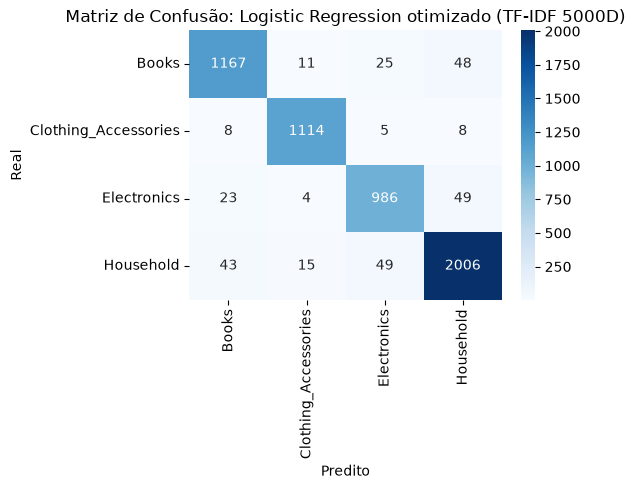

In [9]:
xgb_final = XGBClassifier(**melhores_params_xgb)
xgb_final.fit(X_tr_xgb, y_train)
y_pred_xgb = xgb_final.predict(X_te_xgb)
y_proba_xgb = xgb_final.predict_proba(X_te_xgb)

f1_macro_xgb = f1_score(y_test, y_pred_xgb, average='macro')
f1_weighted_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb, multi_class='ovr', average='macro')
pr_auc_xgb = pr_auc_macro(y_test, y_proba_xgb, le.classes_)

log_final = LogisticRegression(**melhores_params_log)
log_final.fit(X_tr_log, y_train)
y_pred_log = log_final.predict(X_te_log)
y_proba_log = log_final.predict_proba(X_te_log)

f1_macro_log = f1_score(y_test, y_pred_log, average='macro')
f1_weighted_log = f1_score(y_test, y_pred_log, average='weighted')
roc_auc_log = roc_auc_score(y_test, y_proba_log, multi_class='ovr', average='macro')
pr_auc_log = pr_auc_macro(y_test, y_proba_log, le.classes_)

print(f"XGBoost otimizado   ({xgb_reducao} {xgb_dim}D), F1 macro: {f1_macro_xgb:.3f} | F1 weighted: {f1_weighted_xgb:.3f} | ROC-AUC: {roc_auc_xgb:.3f} | PR-AUC macro: {pr_auc_xgb['macro']:.3f}")
print(f"Logistic otimizada  ({log_reducao} {log_dim}D), F1 macro: {f1_macro_log:.3f} | F1 weighted: {f1_weighted_log:.3f} | ROC-AUC: {roc_auc_log:.3f} | PR-AUC macro: {pr_auc_log['macro']:.3f}")
print("\n[Nota] O ROC-AUC dos dois modelos está muito perto de 1 e diferencia pouco entre eles. "
      "Isso é esperado num problema com boa separação entre classes como este. O PR-AUC por classe é "
      "reportado ao lado por ser mais sensível ao desbalanceamento residual entre categorias.")

if f1_macro_xgb >= f1_macro_log:
    modelo_final_nome = 'XGBoost'
    reducao_final, dim_final = xgb_reducao, xgb_dim
    params_finais = melhores_params_xgb
    y_pred_final, y_proba_final = y_pred_xgb, y_proba_xgb
    f1_macro_final, f1_weighted_final, roc_auc_final = f1_macro_xgb, f1_weighted_xgb, roc_auc_xgb
else:
    modelo_final_nome = 'Logistic Regression'
    reducao_final, dim_final = log_reducao, log_dim
    params_finais = melhores_params_log
    y_pred_final, y_proba_final = y_pred_log, y_proba_log
    f1_macro_final, f1_weighted_final, roc_auc_final = f1_macro_log, f1_weighted_log, roc_auc_log

print(f"\nVencedor: {modelo_final_nome} ({reducao_final} {dim_final}D), F1-macro={f1_macro_final:.3f}")

print()
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão: {modelo_final_nome} otimizado ({reducao_final} {dim_final}D)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.savefig('figs/03_matriz_confusao.png', dpi=100)
plt.show()

- Clothing_Accessories: quase sem erro.
- Household: mais erros em número absoluto, confunde em todas as direções.
- Electronics: maior taxa de erro relativa, confunde principalmente com Household.
- Books: erro moderado, também puxado pra Household.
- Erros concentram em torno de Household; as outras classes quase não se confundem entre si.

## 8. A diferença entre os dois finalistas é estatisticamente significativa?

A diferença de F1-macro entre os dois finalistas é pequena. Em vez de só comparar os dois números, testamos com bootstrap pareado sobre o conjunto de teste: reamostramos os mesmos índices de teste muitas vezes, recalculamos a métrica dos dois modelos em cada reamostragem e vemos se a diferença observada é maior do que se esperaria por ruído de amostragem.

In [10]:
resultado_significancia = comparar_modelos_bootstrap(
    y_test, y_pred_log, y_pred_xgb, metrica='f1_macro', n_boot=3000, random_state=42
)
print(f"Diferença observada (Logistic − XGBoost) em F1-macro: {resultado_significancia['diferenca_observada']:+.4f}")
print(f"Intervalo de confiança 95% (bootstrap): [{resultado_significancia['ic_95_baixo']:+.4f}, {resultado_significancia['ic_95_alto']:+.4f}]")
print(f"p-valor (duas caudas): {resultado_significancia['p_valor']:.4f}")
if resultado_significancia['significativo_5pct']:
    print("=> A diferença é estatisticamente significativa ao nível de 5%: não é razoável atribuí-la "
          "só a ruído de amostragem no conjunto de teste.")
else:
    print("=> A diferença NÃO é estatisticamente significativa ao nível de 5%: com esse tamanho de "
          "teste, não dá para descartar que o resultado seja ruído de amostragem, e os dois modelos "
          "deveriam ser considerados estatisticamente equivalentes nesta métrica.")

Diferença observada (Logistic − XGBoost) em F1-macro: +0.0075
Intervalo de confiança 95% (bootstrap): [+0.0017, +0.0133]
p-valor (duas caudas): 0.0120
=> A diferença é estatisticamente significativa ao nível de 5%: não é razoável atribuí-la só a ruído de amostragem no conjunto de teste.


## 9. Interpretabilidade do modelo vencedor

Não basta saber que o modelo classifica bem. Vale abrir o modelo vencedor para ver quais palavras ele está de fato usando para decidir. Com o Logistic Regression sobre TF-IDF como vencedor, foi extraido os coeficientes por classe: cada coeficiente é o peso daquela palavra na decisão daquela categoria especificamente.

In [11]:
if modelo_final_nome == 'Logistic Regression':
    tfidf_final_vectorizer = TfidfVectorizer(max_features=5000, min_df=2)
    tfidf_final_vectorizer.fit(texto_train)  # mesmo vocabulário usado para treinar log_final

    top_palavras = top_features_por_classe(log_final, tfidf_final_vectorizer, le.classes_, top_n=12)
    for classe, dados_classe in top_palavras.items():
        print(f"\n=== {classe} ===")
        print("Palavras a favor (maior coeficiente positivo):")
        for palavra, peso in dados_classe['a_favor']:
            print(f"    {palavra:20s} {peso:+.3f}")
else:
    print(f"O vencedor desta execução foi {modelo_final_nome}, não a Logistic Regression. "
          "A extração de coeficientes por palavra só se aplica a um modelo linear sobre TF-IDF. "
          "Para interpretar um XGBoost, o caminho seria feature importance por ganho (gain) ou SHAP, "
          "não implementado nesta seção.")


=== Books ===
Palavras a favor (maior coeficiente positivo):
    booklist             +4.941
    first                +4.333
    authored             +4.188
    guest                +3.413
    gala                 +3.283
    activated            +3.165
    mumbai               +3.060
    household            +3.015
    polymer              +2.974
    trained              +2.929
    own                  +2.881
    familiar             +2.828

=== Clothing_Accessories ===
Palavras a favor (maior coeficiente positivo):
    woman                +7.328
    memories             +7.068
    sunday               +6.379
    gifts                +5.878
    bpa                  +5.854
    cost                 +5.819
    bracelet             +5.390
    socket               +4.328
    uniquely             +4.115
    itself               +4.013
    wealth               +3.827
    gifting              +3.820

=== Electronics ===
Palavras a favor (maior coeficiente positivo):
    languages            

## 10. Análise dos erros

In [12]:
erros = pd.DataFrame({
    'texto': [t[:120] for t in texto_test],
    'categoria_real': le.inverse_transform(y_test),
    'categoria_prevista': le.inverse_transform(y_pred_final),
})
erros_apenas = erros[erros['categoria_real'] != erros['categoria_prevista']]
print(f"Total de erros: {len(erros_apenas)} de {len(erros)} ({len(erros_apenas) / len(erros) * 100:.1f}%)")
display(erros_apenas.sample(min(10, len(erros_apenas)), random_state=42))

Total de erros: 288 de 5561 (5.2%)


,texto,categoria_real,categoria_prevista
928,Quantum QHM500-8LM S Webcam (Black) A proven i...,Electronics,Books
2783,Rasper Acrylic Table Top Elevator (Big Size 24...,Electronics,Household
5000,Opolar LC06 B01E3Q7FS6LO Laptop Fan Cooler wit...,Electronics,Household
882,DEMIDEL Digital Infrared Forehead Instant Read...,Household,Electronics
3200,Aaiffel Reusable Waterproof Household Latex Gl...,Clothing_Accessories,Household
285,Corsair Air Series SP120 LED PC Case Fan (Red)...,Electronics,Household
929,Quick Sense (Qs-H1) 220v -118 dB Hooter Alarm ...,Household,Electronics
3061,Drishti To The Point 2018 BOOK FOR UPSC MAINS ...,Electronics,Books
1419,Uniqus 45mm 0-9 3D Metal House Door Auto Car A...,Household,Electronics
3541,Azacus Long Arm Study Desk Light with 3 Shades...,Household,Electronics


- Maioria: produtos ambíguos Electronics↔Household (fan, cooler, termômetro, alarme, luminária).
- O livro do UPSC rotulado "Electronics" é provável erro de rótulo, não erro do modelo, sinal de que a performance real pode ser melhor do que o número sugere.

In [13]:
pares_confusao = (
    erros_apenas.groupby(['categoria_real', 'categoria_prevista'])
    .size()
    .reset_index(name='quantidade')
    .sort_values('quantidade', ascending=False)
)
print("Pares de categorias mais confundidos:")
display(pares_confusao.head(10))

Pares de categorias mais confundidos:


,categoria_real,categoria_prevista,quantidade
8,Electronics,Household,49
11,Household,Electronics,49
2,Books,Household,48
9,Household,Books,43
1,Books,Electronics,25
6,Electronics,Books,23
10,Household,Clothing_Accessories,15
0,Books,Clothing_Accessories,11
3,Clothing_Accessories,Books,8
5,Clothing_Accessories,Household,8
